In [44]:
import pandas as pd
df = pd.read_csv('../data/raw/listings.csv')

In [45]:
missing_prices = df['price'].isna().sum()

print(f"Number of missing values in 'price': {missing_prices}")

Number of missing values in 'price': 953


In [46]:

import sys
import os

sys.path.append(os.path.abspath('..'))

from src.helpers.clean_target import clean_missing_target


input_file = '../data/raw/listings.csv'
output_file = '../data/processed/airbnb_rio_cleaned_target.csv'

clean_missing_target(input_file, output_file);

Reading ../data/raw/listings.csv...

--- Processing Summary ---
Initial row count:          40769
Rows with missing 'price': 953 (Removed)
Remaining row count:        39816
Cleaned data saved to:      ../data/processed/airbnb_rio_cleaned_target.csv



In [47]:
df = pd.read_csv('../data/processed/airbnb_rio_cleaned_target.csv')
print(f"Dataset created with shape: {df.shape}")

Dataset created with shape: (39816, 90)


In [48]:
import pandas as pd

# 1. Read your newly created clean target file
df_clean_target = pd.read_csv('../data/processed/airbnb_rio_cleaned_target.csv')

# 2. Select only the numerical columns to investigate
# (This automatically grabs integers and floats)
numerical_df = df_clean_target.select_dtypes(include=['int64', 'float64'])

# 3. Check for missing values in these numerical columns
missing_summary = numerical_df.isna().sum()
missing_percentage = (numerical_df.isna().mean() * 100)

# Combine into a nice summary table
numerical_status = pd.DataFrame({
    'Missing Values': missing_summary,
    'Percentage (%)': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print(numerical_status)

                              Missing Values  Percentage (%)
host_total_listings_count              39816           100.0
host_response_rate                     39816           100.0
neighbourhood_group_cleansed           39816           100.0
neighbourhood                          39816           100.0
host_verifications                     39816           100.0
...                                      ...             ...
availability_90                            0             0.0
availability_60                            0             0.0
availability_30                            0             0.0
maximum_nights_avg_ntm                     0             0.0
id                                         0             0.0

[62 rows x 2 columns]


In [56]:
# Check the datatype of the 'id' column
print(f"The datatype of 'id' is: {df_numeric_clean['id'].dtype}")

# Your existing print statement
print(f"Dataset created with shape: {df_numeric_clean[df_numeric_clean['id'] == id].shape}")

The datatype of 'id' is: int64
Dataset created with shape: (0, 76)


In [59]:
# Calculate the percentage of non-null values in the 'id' column
percentage_present = df_numeric_clean['id'].notna().mean() * 100

print(f"Percentage of values present in 'id': {percentage_present:.2f}%")

Percentage of values present in 'id': 100.00%


In [66]:

from src.helpers.numerical_processing import clean_numerical_features

# Load the data we saved from the last step
df_input = pd.read_csv('../data/processed/airbnb_rio_cleaned_target.csv')

# Run the cleaning processing
df_numeric_clean = clean_numerical_features(df_input)

Dropping columns with >90.0% missing values:
 - neighborhood_overview
 - host_since
 - host_response_time
 - host_response_rate
 - host_acceptance_rate
 - host_thumbnail_url
 - host_neighbourhood
 - host_total_listings_count
 - host_verifications
 - neighbourhood
 - neighbourhood_group_cleansed
 - calendar_updated
 - license
 - instant_bookable

Imputed 25 numerical columns using their median value.


In [67]:
print(f"Dataset created with shape: {df_numeric_clean.shape}")

Dataset created with shape: (39816, 76)


In [72]:
print(df_numeric_clean.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_is_superhost', 'host_picture_url', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability

In [75]:
import importlib
from src.helpers import feature_selection as feature_selection_module

# Reload the helper so Jupyter uses the latest saved code
feature_selection_module = importlib.reload(feature_selection_module)
select_important_features = feature_selection_module.select_important_features

df_final_features = select_important_features(df_numeric_clean)

print("id present in df_final_features:", 'id' in df_final_features.columns)
print(df_final_features.columns.tolist())

--- Running Feature Selection ---
Original unique columns: 76
Filtered columns retained: 24
id present in df_final_features: True
['id', 'price', 'latitude', 'longitude', 'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'host_is_superhost', 'host_listings_count', 'hosts_time_as_host_years', 'minimum_nights', 'maximum_nights', 'availability_365', 'has_availability', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'description']


In [76]:
print(f"Dataset created with shape: {df_final_features.shape}")

Dataset created with shape: (39816, 24)


In [77]:
print(df_final_features.columns.tolist())

['id', 'price', 'latitude', 'longitude', 'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'host_is_superhost', 'host_listings_count', 'hosts_time_as_host_years', 'minimum_nights', 'maximum_nights', 'availability_365', 'has_availability', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'description']


In [78]:
# Look at the mean, min, max, and percentiles of your numerical columns
df_final_features.describe()

,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,host_listings_count,hosts_time_as_host_years,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month
count,3.981600e+04,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000,39816.000000
mean,9.895167e+17,-22.963868,-43.245751,3.965994,1.446617,1.470163,2.355862,14.685528,4.859956,2.045258,452.132811,211.211799,29.256053,4.827715,1.351349
std,5.966675e+17,0.036967,0.101117,2.279921,0.938446,0.969205,2.085060,45.940407,4.188780,1.212543,413.793990,119.070590,51.908095,0.337693,1.286006
min,1.787800e+04,-23.072920,-43.710380,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000
25%,6.545650e+17,-22.984041,-43.276475,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,90.000000,89.000000,1.000000,4.810000,0.490000
50%,1.218859e+18,-22.970153,-43.192400,4.000000,1.000000,1.000000,2.000000,2.000000,3.000000,2.000000,365.000000,213.000000,9.000000,4.920000,1.000000
75%,1.501588e+18,-22.945078,-43.183458,5.000000,2.000000,2.000000,3.000000,9.000000,9.000000,3.000000,730.000000,340.000000,34.000000,5.000000,1.810000
max,1.652324e+18,-22.750510,-43.104400,16.000000,18.000000,27.000000,50.000000,772.000000,15.000000,30.000000,1125.000000,365.000000,793.000000,5.000000,29.010000


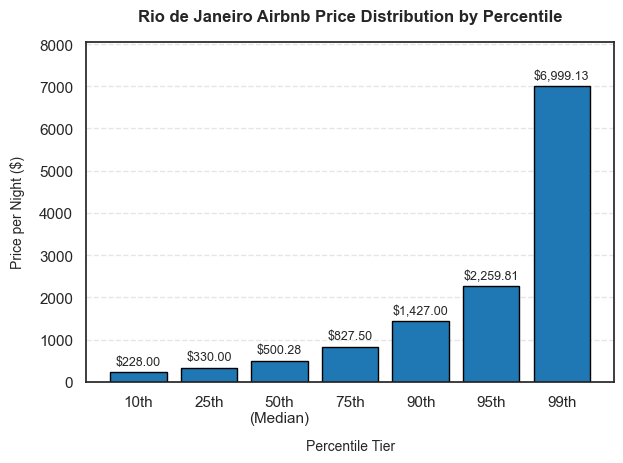

In [79]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean the 'price' column strings and convert to actual numbers first
df['price'] = df['price'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 2. Setup percentile definitions
percentile_levels = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
percentile_labels = ['10th', '25th', '50th\n(Median)', '75th', '90th', '95th', '99th']

# 3. Calculate values dynamically
values = df['price'].quantile(percentile_levels).tolist()

# 4. Create the chart
bars = plt.bar(percentile_labels, values, color='#1f77b4', edgecolor='black')

# 5. Add text values on top of each bar
max_val = max(values)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max_val * 0.015), f"${yval:,.2f}", ha='center', va='bottom', fontsize=9)

# 6. Customize presentation
plt.title('Rio de Janeiro Airbnb Price Distribution by Percentile', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Percentile Tier', fontsize=10, labelpad=10)
plt.ylabel('Price per Night ($)', fontsize=10, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max_val * 1.15)

plt.tight_layout()
plt.show()

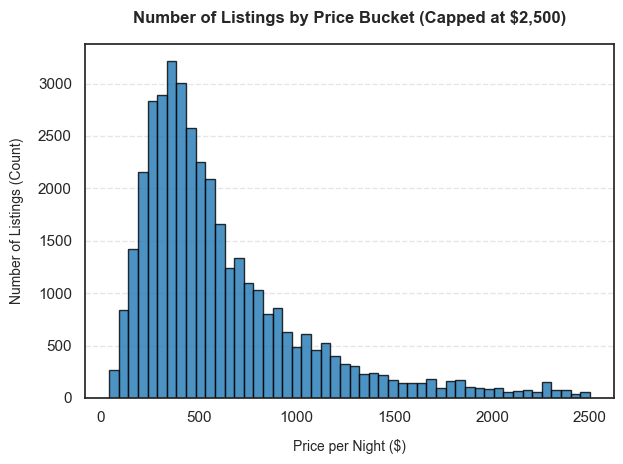

In [80]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter out the extreme luxury outliers just for this visualization 
# so the chart doesn't look squished
# Clean the price column: remove '$' and ',' then convert to float
df_final_features['price'] = (
    df_final_features['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_final_features['price'] = pd.to_numeric(df_final_features['price'], errors='coerce')

# Drop any rows where price could not be converted (NaN)
df_final_features = df_final_features.dropna(subset=['price'])

# --- Your original code now works smoothly ---
df_filtered_plot = df_final_features[df_final_features['price'] <= 2500]

# 2. Plot the histogram (Price Buckets)
# bins=50 creates 50 evenly spaced price ranges between $0 and $2500
plt.hist(df_filtered_plot['price'], bins=50, color='#1f77b4', edgecolor='black', alpha=0.8)

# 3. Customize the chart labels
plt.title('Number of Listings by Price Bucket (Capped at $2,500)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Price per Night ($)', fontsize=10, labelpad=10)
plt.ylabel('Number of Listings (Count)', fontsize=10, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Show the plot
plt.tight_layout()
plt.show()

In [81]:
max_price = df_final_features['price'].max()
print(f"The maximum price in the dataset is: ${max_price:,.2f}")

The maximum price in the dataset is: $570,726.00


In [82]:

from src.helpers.outlier_detection import remove_price_outliers_dynamic

df_final_features = remove_price_outliers_dynamic(df_final_features, min_price_threshold=10, percentile_cutoff=0.99)

--- Running Dynamic Outlier Removal ---
Calculated 99.0th percentile threshold: $6,999.13
Removed 399 listing(s) outside the range [$10 - $6,999.13].
New maximum price in dataset: $6,990.00


In [83]:
print(f"Dataset created with shape: {df_final_features.shape}")
print(f"Dataset created with shape: {df_final_features.shape}")

Dataset created with shape: (39417, 24)
Dataset created with shape: (39417, 24)


In [84]:
# 1. Get all numerical features (floats and integers)
numeric_cols = df_final_features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Get all categorical/text features (objects)
object_cols = df_final_features.select_dtypes(include=['object']).columns.tolist()

print("--- Numerical Features ---")
print(numeric_cols)

print("\n--- Categorical & Text Features ---")
print(object_cols)

--- Numerical Features ---
['id', 'price', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'host_listings_count', 'hosts_time_as_host_years', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month']

--- Categorical & Text Features ---
['neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'amenities', 'host_is_superhost', 'has_availability', 'description']


Analysis complete! High-resolution plot saved as 'numerical_features_vs_price.png'


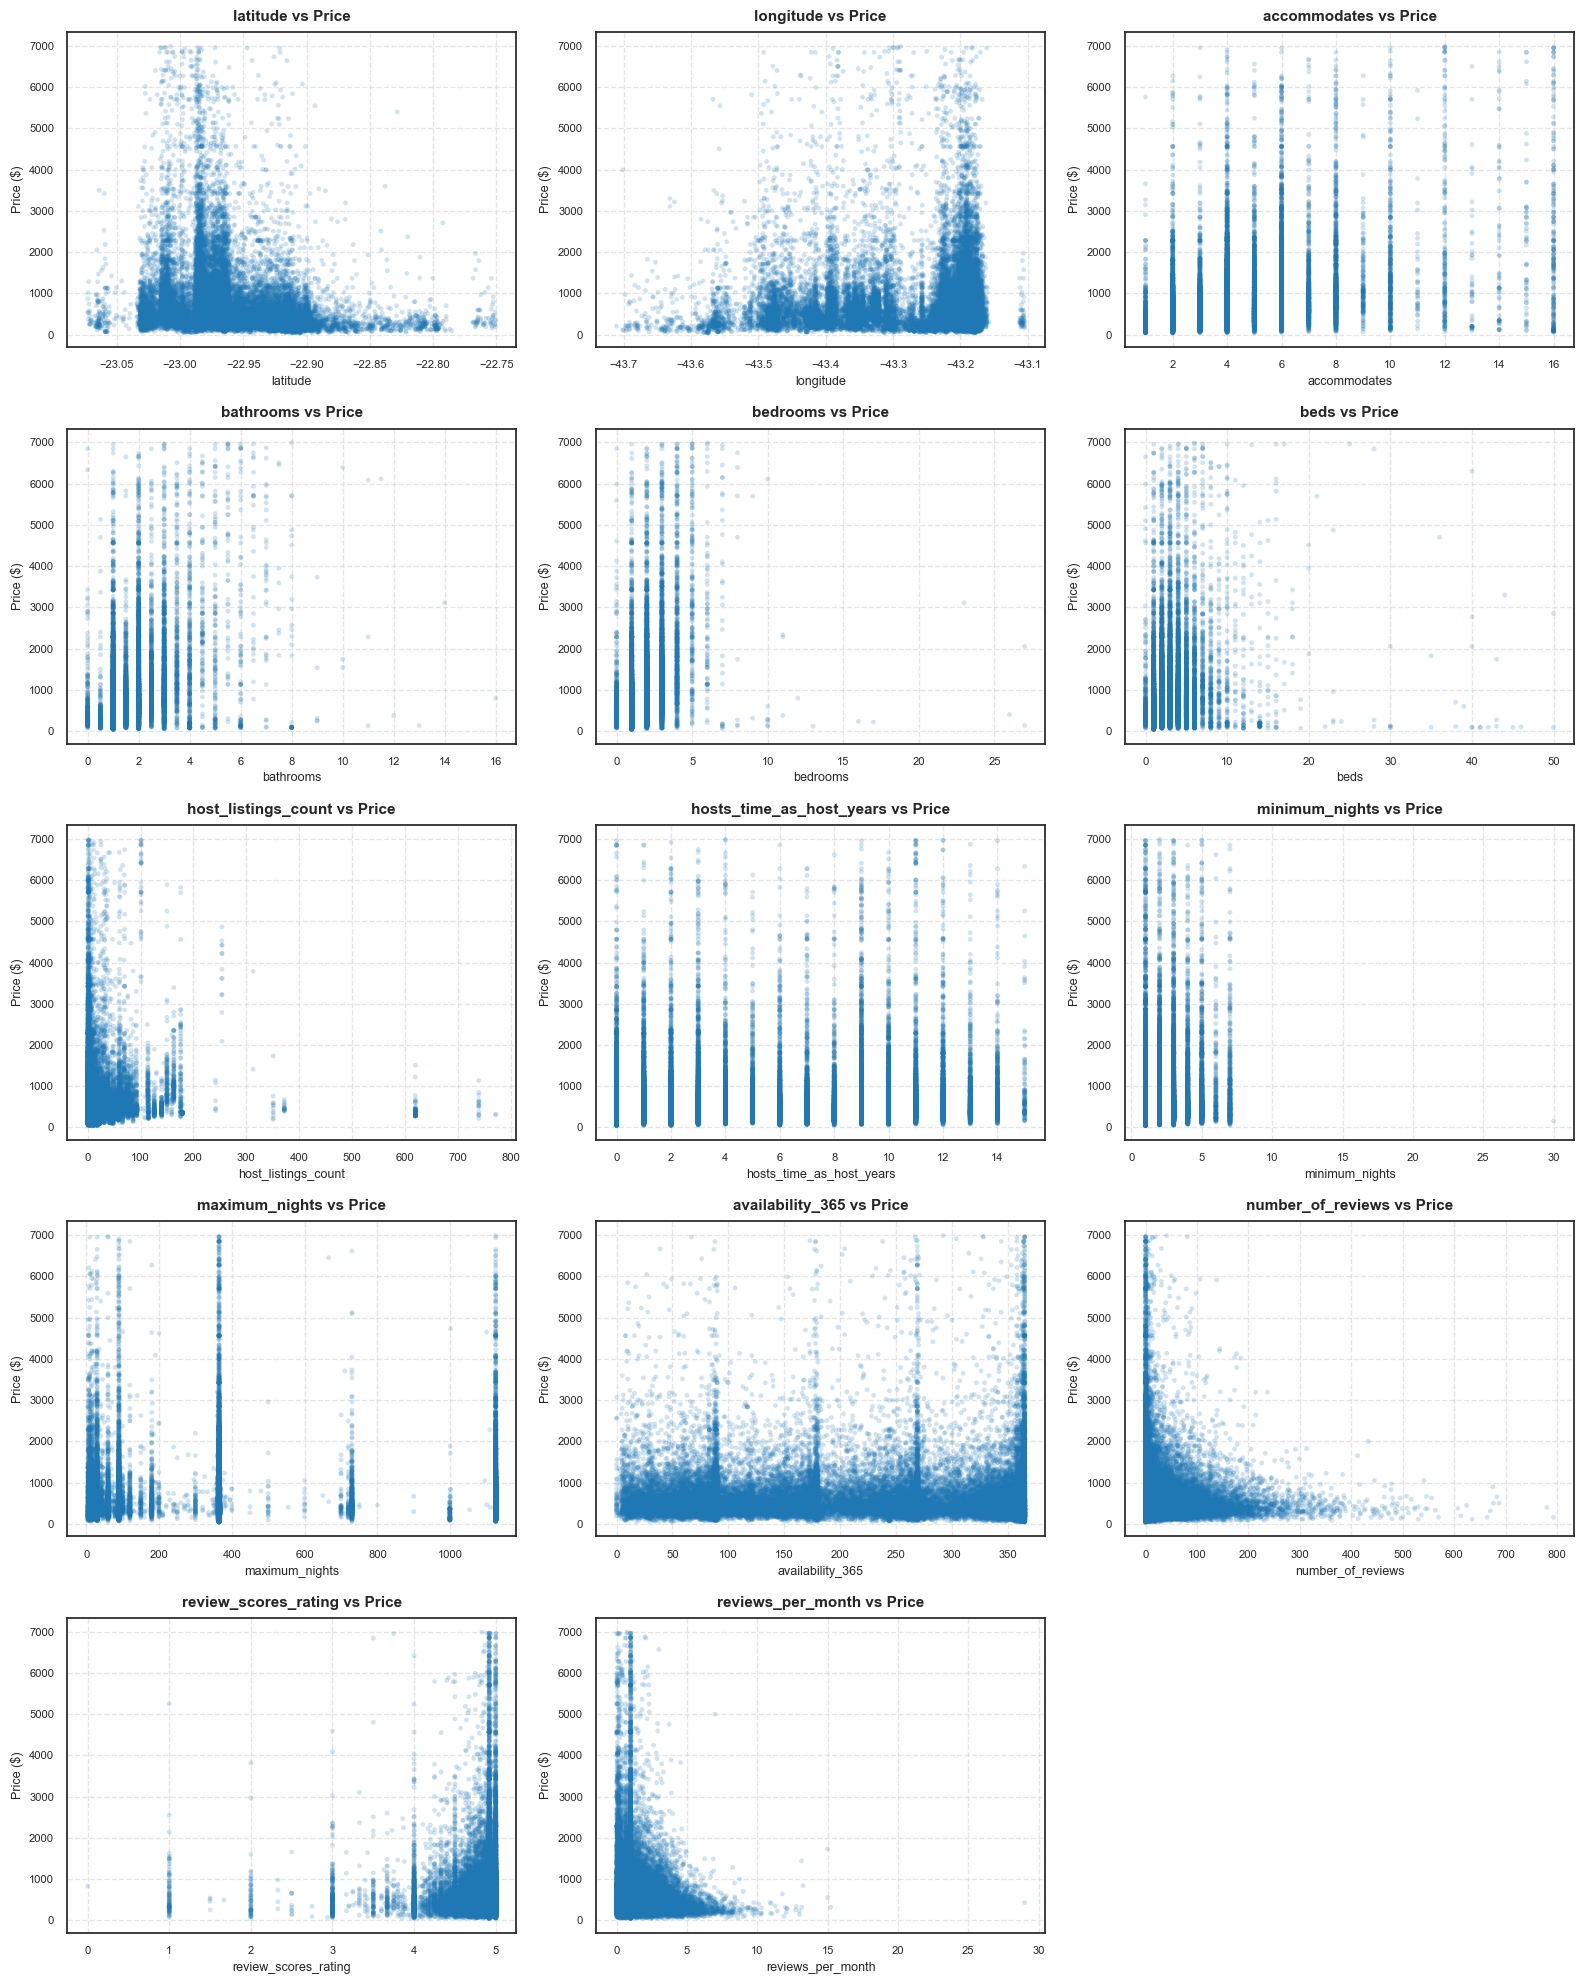

In [85]:
import matplotlib.pyplot as plt
import math

# 1. Identify all numerical features to plot (excluding the target 'price')
numeric_features = [
    'latitude', 'longitude', 'accommodates', 'bathrooms', 
    'bedrooms', 'beds', 'host_listings_count', 'hosts_time_as_host_years', 
    'minimum_nights', 'maximum_nights', 'availability_365', 
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month'
]

# 2. Dynamically calculate grid dimensions (3 columns wide)
num_cols = 3
num_rows = math.ceil(len(numeric_features) / num_cols)

# 3. Create subplots framework
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 4))
axes = axes.flatten()  # Flatten the 2D array of axes to easily loop over them

# 4. Loop through each numerical feature and construct its scatter plot
for i, feature in enumerate(numeric_features):
    if feature in df_final_features.columns:
        # We use alpha=0.20 to make points semi-transparent to easily spot data overlap/density
        axes[i].scatter(df_final_features[feature], df_final_features['price'], alpha=0.2, color='#1f77b4', edgecolors='none', s=12)
        
        # Format individual subplots safely to ensure text readability
        axes[i].set_title(f'{feature} vs Price', fontsize=11, fontweight='bold', pad=8)
        axes[i].set_xlabel(feature, fontsize=9, labelpad=4)
        axes[i].set_ylabel('Price ($)', fontsize=9, labelpad=4)
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].tick_params(axis='both', labelsize=8)

# 5. Remove empty subplot cells at the bottom right of the grid layout
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Apply tight constraints and save the visualization matrix
plt.tight_layout()
plt.savefig('numerical_features_vs_price.png', dpi=300)
print("Analysis complete! High-resolution plot saved as 'numerical_features_vs_price.png'")

In [26]:
import sys
print("Jupyter is using this Python executable:")
print(sys.executable)
print("\nJupyter is looking for packages in these paths:")
print(sys.path)

Jupyter is using this Python executable:
/opt/anaconda3/envs/autogluon_env/bin/python

Jupyter is looking for packages in these paths:
['/opt/anaconda3/envs/autogluon_env/lib/python311.zip', '/opt/anaconda3/envs/autogluon_env/lib/python3.11', '/opt/anaconda3/envs/autogluon_env/lib/python3.11/lib-dynload', '', '/opt/anaconda3/envs/autogluon_env/lib/python3.11/site-packages', '/Users/jnanadeep/Desktop/airbnb-price-prediction', '/Users/jnanadeep/Desktop/airbnb-price-prediction']


      LOW CARDINALITY FEATURES STATS SUMMARY       

--- Feature: room_type ---
                 count  median_price
room_type                           
Hotel room          13         571.0
Entire home/apt  32424         542.5
Private room      6399         311.0
Shared room        581         143.0
--------------------------------------------------

--- Feature: bathrooms_clean ---
                 count  median_price
bathrooms_clean                     
11.5                 1      6109.000
6.5                 28      4708.430
5.5                 50      4125.580
7                   36      3747.835
7.5                  8      3278.040
14                   1      3110.000
4.5                109      2377.670
11                   3      2283.000
10                   3      1740.500
5                  131      1712.000
6                   86      1596.835
3.5                312      1577.005
4                  353      1337.760
3                 1414      1102.415
2.5                89

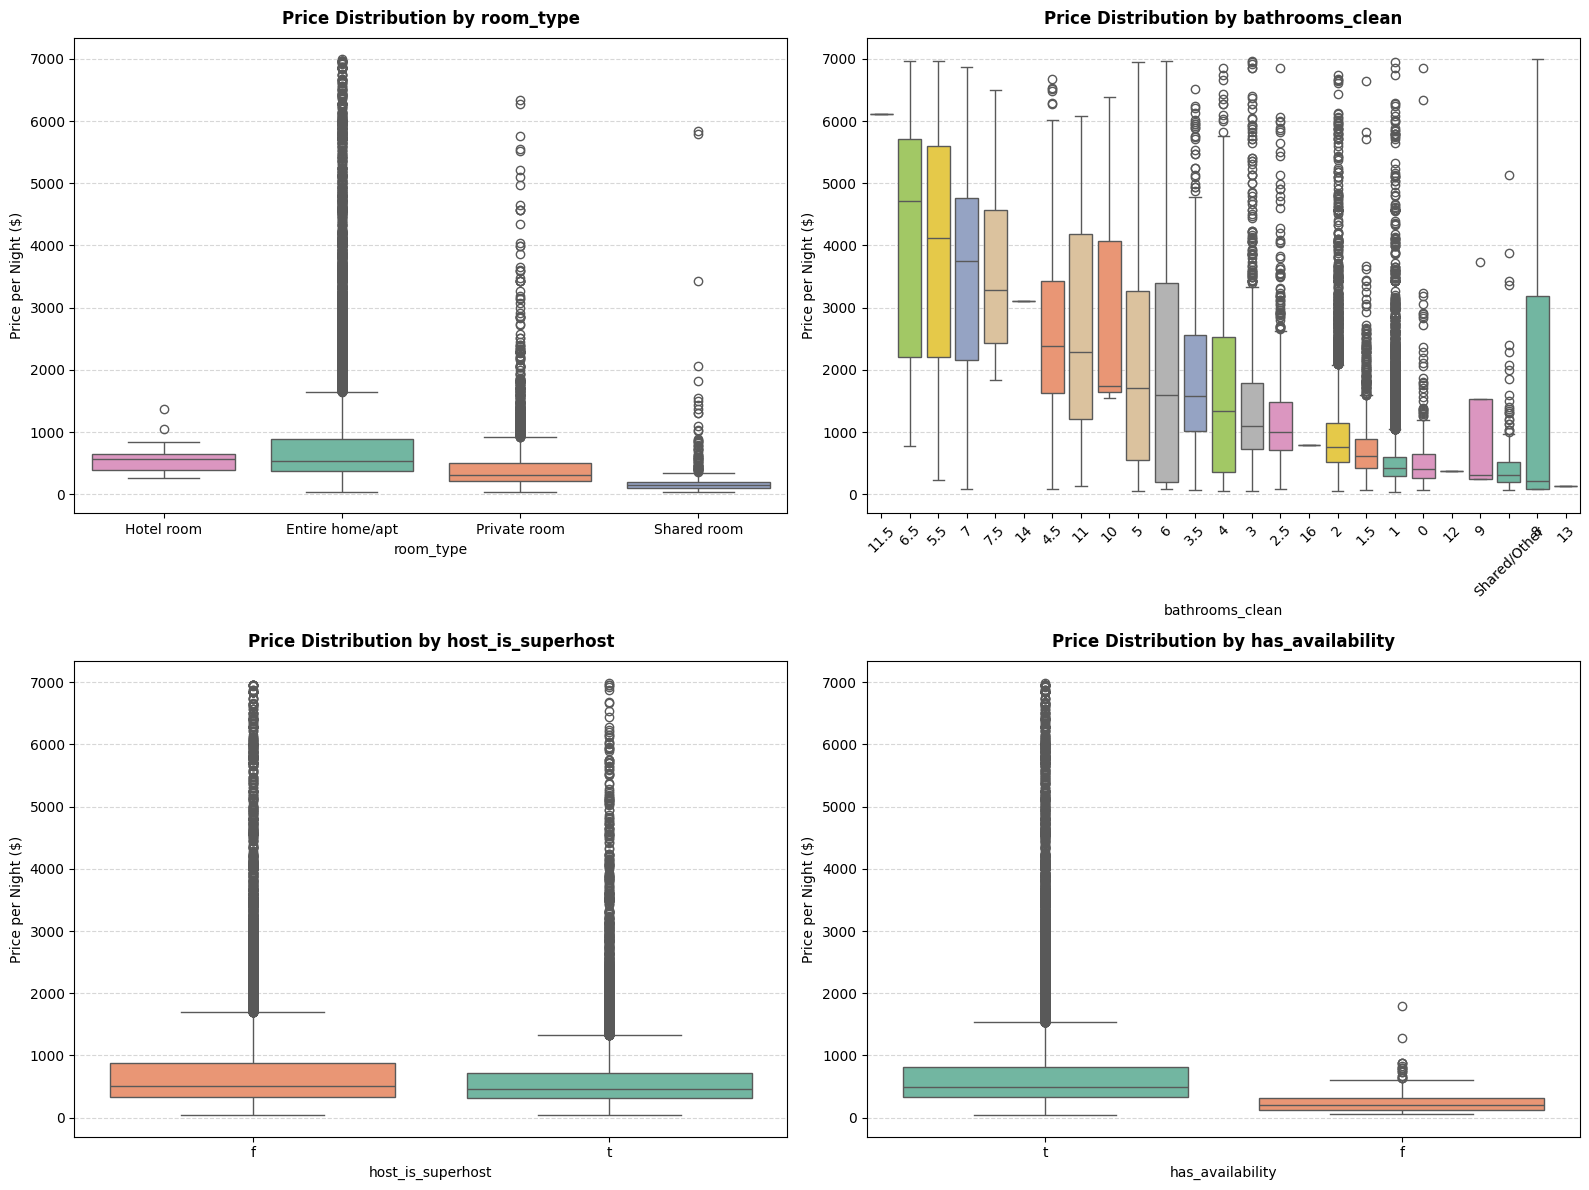

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 1. Quick preprocessing for 'bathrooms_text' to clean up low-count variations
# This groups them by the number at the start of the string (e.g., "1.5 baths" -> "1.5")
df_final_features['bathrooms_clean'] = df_final_features['bathrooms_text'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
df_final_features['bathrooms_clean'] = df_final_features['bathrooms_clean'].fillna('Shared/Other')

# Update our target list of low cardinality features
low_card_features = ['room_type', 'bathrooms_clean', 'host_is_superhost', 'has_availability']

# 2. PRINT STATISTICAL SUMMARIES (Value Counts & Median Prices)
print("==================================================")
print("      LOW CARDINALITY FEATURES STATS SUMMARY       ")
print("==================================================\n")

for col in low_card_features:
    print(f"--- Feature: {col} ---")
    # Calculate frequency count and median price for each group
    summary = df_final_features.groupby(col).agg(
        count=(col, 'count'),
        median_price=('price', 'median')
    ).sort_values(by='median_price', ascending=False)
    print(summary)
    print("-" * 50 + "\n")

# 3. PLOT MULTIPLE BOX PLOTS IN A GRID
# Setup a 2x2 layout matrix for our 4 features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(low_card_features):
    # Sort categories by median price so the boxplot reads cleanly left-to-right
    order = df_final_features.groupby(col)['price'].median().sort_values(ascending=False).index
    
    # Generate the boxplot
    sns.boxplot(
        data=df_final_features, 
        x=col, 
        y='price', 
        ax=axes[i], 
        order=order, 
        palette='Set2',
        hue=col,
        legend=False
    )
    
    # Custom adjustments for visuals
    axes[i].set_title(f'Price Distribution by {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Price per Night ($)', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
    # Rotate text labels on the x-axis if there are many categories (like bathrooms)
    if len(order) > 4:
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

     HIGH CARDINALITY FEATURES DATA EXPLORATION    

Total Unique Neighborhoods: 155
Neighborhoods with >= 10 listings: 101

--- Top 10 Most Expensive Reliable Neighborhoods (Median) ---
                        listing_count  median_price   mean_price
neighbourhood_cleansed                                          
Joá                                73      1758.000  2783.301233
Leblon                           1591       889.000  1169.322432
Lagoa                             243       852.000  1180.648395
Ipanema                          3212       793.000  1068.115579
São Conrado                       211       776.000  1270.781991
Sepetiba                           11       742.000   562.838182
Alto da Boa Vista                  40       690.545  1233.073250
Gávea                             190       686.835  1108.980211
Barra da Tijuca                  3053       656.500   945.717619
Inhaúma                            14       603.135   581.840714

--- Top 10 Most Common Property 

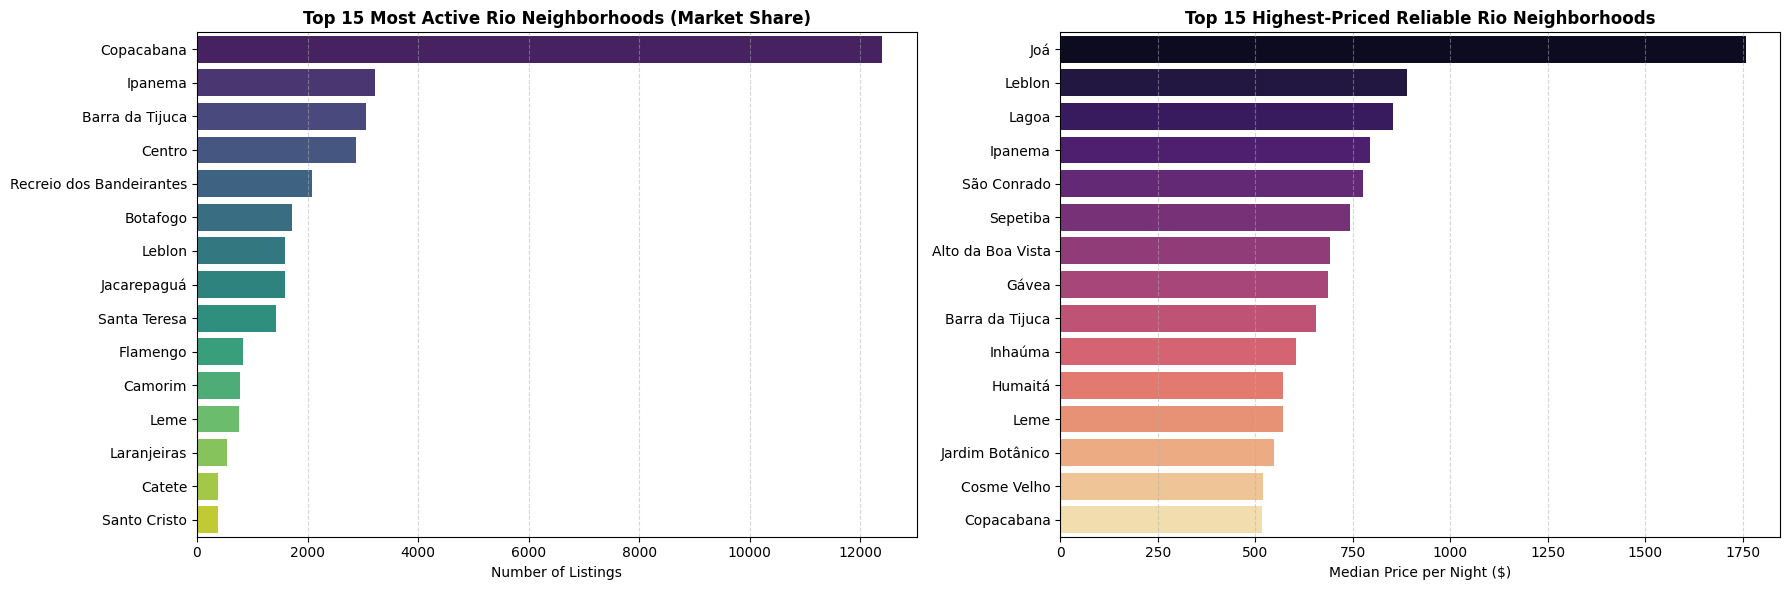

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("==================================================")
print("     HIGH CARDINALITY FEATURES DATA EXPLORATION    ")
print("==================================================\n")

# --- 1. NEIGHBORHOOD ANALYSIS ---
# Calculate volume and price metrics for neighborhoods
neigh_stats = df_final_features.groupby('neighbourhood_cleansed').agg(
    listing_count=('price', 'count'),
    median_price=('price', 'median'),
    mean_price=('price', 'mean')
)

# Filter for neighborhoods with a reliable sample size (e.g., more than 10 listings)
reliable_neighs = neigh_stats[neigh_stats['listing_count'] >= 10]

print(f"Total Unique Neighborhoods: {len(neigh_stats)}")
print(f"Neighborhoods with >= 10 listings: {len(reliable_neighs)}")
print("\n--- Top 10 Most Expensive Reliable Neighborhoods (Median) ---")
print(reliable_neighs.sort_values(by='median_price', ascending=False).head(10))

# --- 2. PROPERTY TYPE ANALYSIS ---
prop_stats = df_final_features.groupby('property_type').agg(
    listing_count=('price', 'count'),
    median_price=('price', 'median')
).sort_values(by='listing_count', ascending=False)

print("\n--- Top 10 Most Common Property Types & Their Median Price ---")
print(prop_stats.head(10))


# --- 3. VISUALIZE THE MARKET SHARE VS PRICE DRIVERS ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Top 15 Neighborhoods by Volume
top_vol_neighs = reliable_neighs.sort_values(by='listing_count', ascending=False).head(15)
sns.barplot(
    x=top_vol_neighs['listing_count'], 
    y=top_vol_neighs.index, 
    ax=axes[0], 
    palette='viridis',
    hue=top_vol_neighs.index,
    legend=False
)
axes[0].set_title('Top 15 Most Active Rio Neighborhoods (Market Share)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Plot Top 15 Neighborhoods by Median Price
top_exp_neighs = reliable_neighs.sort_values(by='median_price', ascending=False).head(15)
sns.barplot(
    x=top_exp_neighs['median_price'], 
    y=top_exp_neighs.index, 
    ax=axes[1], 
    palette='magma',
    hue=top_exp_neighs.index,
    legend=False
)
axes[1].set_title('Top 15 Highest-Priced Reliable Rio Neighborhoods', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Median Price per Night ($)')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

          TEXT & LIST FEATURE CORRELATION         

Correlation (Amenity Count vs Price):   0.0343
Correlation (Description Words vs Price): -0.0389


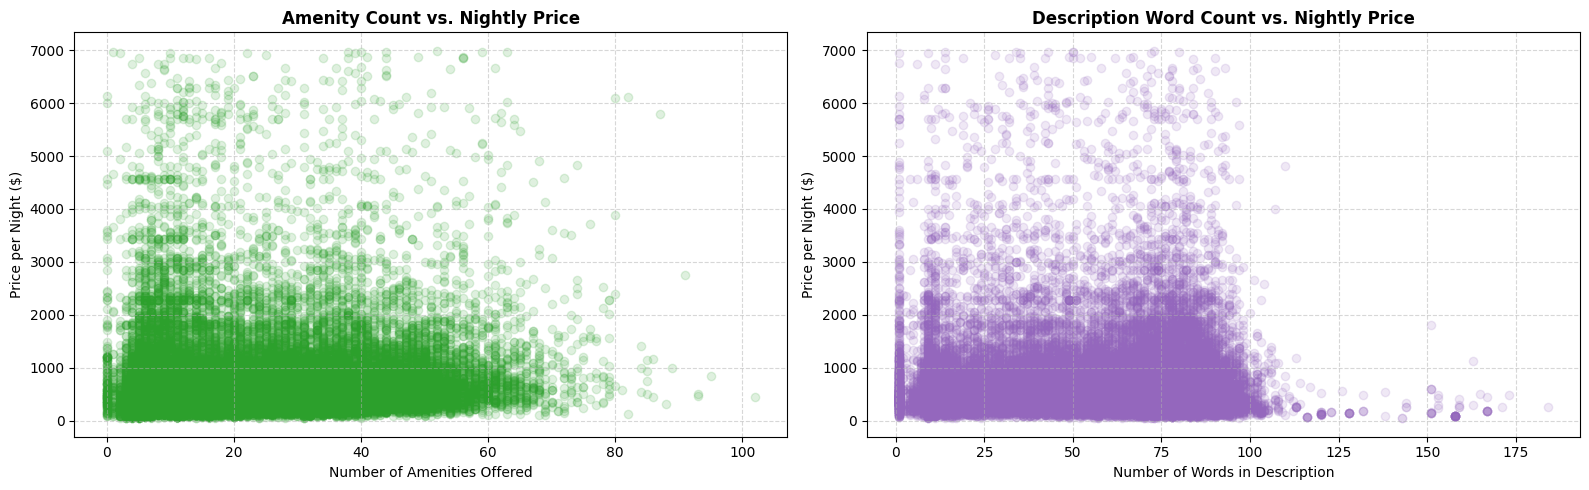

In [29]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Safe parsing function to count individual amenity tags
def count_amenities(x):
    if pd.isna(x):
        return 0
    try:
        # If it's stored as a string representation of a list: "['Wifi', 'Pool']"
        return len(ast.literal_eval(str(x)))
    except:
        # Fallback if it's just a raw comma-separated string
        return len(str(x).split(','))

# 2. Engineer temporary text-based metrics for EDA
df_final_features['amenity_count'] = df_final_features['amenities'].apply(count_amenities)
df_final_features['desc_word_count'] = df_final_features['description'].astype(str).apply(lambda x: len(x.split()))

# 3. Print out correlation metrics
print("==================================================")
print("          TEXT & LIST FEATURE CORRELATION         ")
print("==================================================\n")
print(f"Correlation (Amenity Count vs Price):   {df_final_features['amenity_count'].corr(df_final_features['price']):.4f}")
print(f"Correlation (Description Words vs Price): {df_final_features['desc_word_count'].corr(df_final_features['price']):.4f}")

# 4. Visualize the distributions against price
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Amenity Count vs Price
axes[0].scatter(df_final_features['amenity_count'], df_final_features['price'], alpha=0.15, color='#2ca02c')
axes[0].set_title('Amenity Count vs. Nightly Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Amenities Offered')
axes[0].set_ylabel('Price per Night ($)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Description Word Count vs Price
axes[1].scatter(df_final_features['desc_word_count'], df_final_features['price'], alpha=0.15, color='#9467bd')
axes[1].set_title('Description Word Count vs. Nightly Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Words in Description')
axes[1].set_ylabel('Price per Night ($)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

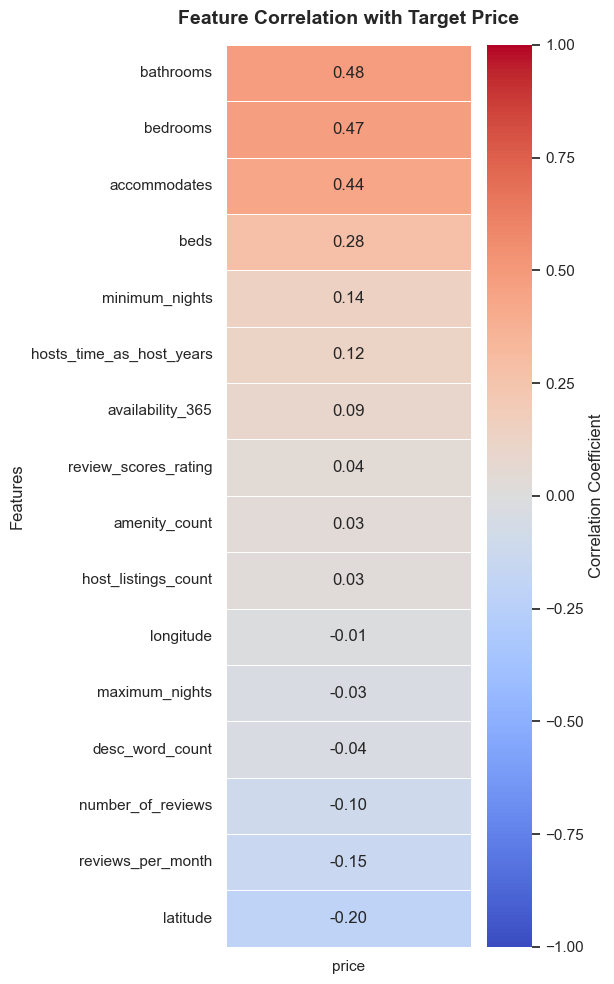

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Isolate numerical features and compute the full correlation matrix
numerical_df = df_final_features.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# 2. Isolate just the target 'price' column and sort the values
# We drop 'price' itself so it doesn't show a perfect 1.0 correlation with itself
price_corr = corr_matrix[['price']].drop(labels=['price']).sort_values(by='price', ascending=False)

# 3. Design a beautiful, modern single-column heatmap
plt.figure(figsize=(6, 10))
sns.set_theme(style="white")

# Using a diverging palette (Red for positive correlation, Blue for negative)
sns.heatmap(
    price_corr, 
    annot=True,             # Show the correlation numbers inside the squares
    fmt=".2f",              # Round numbers to 2 decimal places
    cmap="coolwarm",        # Color gradient (Red = expensive, Blue = cheaper)
    vmin=-1, vmax=1,        # Lock standard correlation boundaries
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5
)

plt.title("Feature Correlation with Target Price", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
import numpy as np

# 1. Select only the numerical columns from your dataframe
numerical_df = df_final_features.select_dtypes(include=[np.number])

# 2. Compute the full correlation matrix
full_corr_matrix = numerical_df.corr()

# 3. Print it out cleanly, rounded to 2 decimal places for easy reading
print("=======================================================================")
print("                      FULL CORRELATION MATRIX                          ")
print("=======================================================================")
display(full_corr_matrix.round(2))

                      FULL CORRELATION MATRIX                          


,price,latitude,longitude,accommodates,bathrooms,bedrooms,beds,host_listings_count,hosts_time_as_host_years,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,amenity_count,desc_word_count
price,1.00,-0.20,-0.01,0.44,0.48,0.47,0.28,0.03,0.12,0.14,-0.03,0.09,-0.10,0.04,-0.15,0.03,-0.04
latitude,-0.20,1.00,0.39,-0.12,-0.15,-0.15,-0.07,0.04,-0.07,-0.07,0.01,0.04,-0.06,0.00,0.03,-0.10,0.02
longitude,-0.01,0.39,1.00,-0.13,-0.12,-0.14,-0.08,0.06,0.10,0.08,-0.03,-0.17,0.09,-0.02,0.08,0.00,0.08
accommodates,0.44,-0.12,-0.13,1.00,0.54,0.64,0.64,0.01,0.03,0.05,0.03,0.07,-0.01,-0.01,-0.03,0.11,0.05
bathrooms,0.48,-0.15,-0.12,0.54,1.00,0.66,0.49,0.01,0.09,0.10,-0.00,0.07,-0.04,0.00,-0.10,0.08,0.02
bedrooms,0.47,-0.15,-0.14,0.64,0.66,1.00,0.55,0.01,0.07,0.10,-0.01,0.06,-0.06,0.01,-0.10,0.08,0.01
beds,0.28,-0.07,-0.08,0.64,0.49,0.55,1.00,0.00,0.07,0.02,0.03,0.05,0.00,-0.02,-0.05,0.11,0.05
host_listings_count,0.03,0.04,0.06,0.01,0.01,0.01,0.00,1.00,0.14,-0.04,0.01,0.07,-0.04,-0.09,-0.00,-0.03,0.00
hosts_time_as_host_years,0.12,-0.07,0.10,0.03,0.09,0.07,0.07,0.14,1.00,0.18,0.10,-0.03,0.23,-0.05,-0.17,0.09,-0.06
minimum_nights,0.14,-0.07,0.08,0.05,0.10,0.10,0.02,-0.04,0.18,1.00,-0.07,-0.07,-0.07,0.02,-0.22,-0.03,-0.03


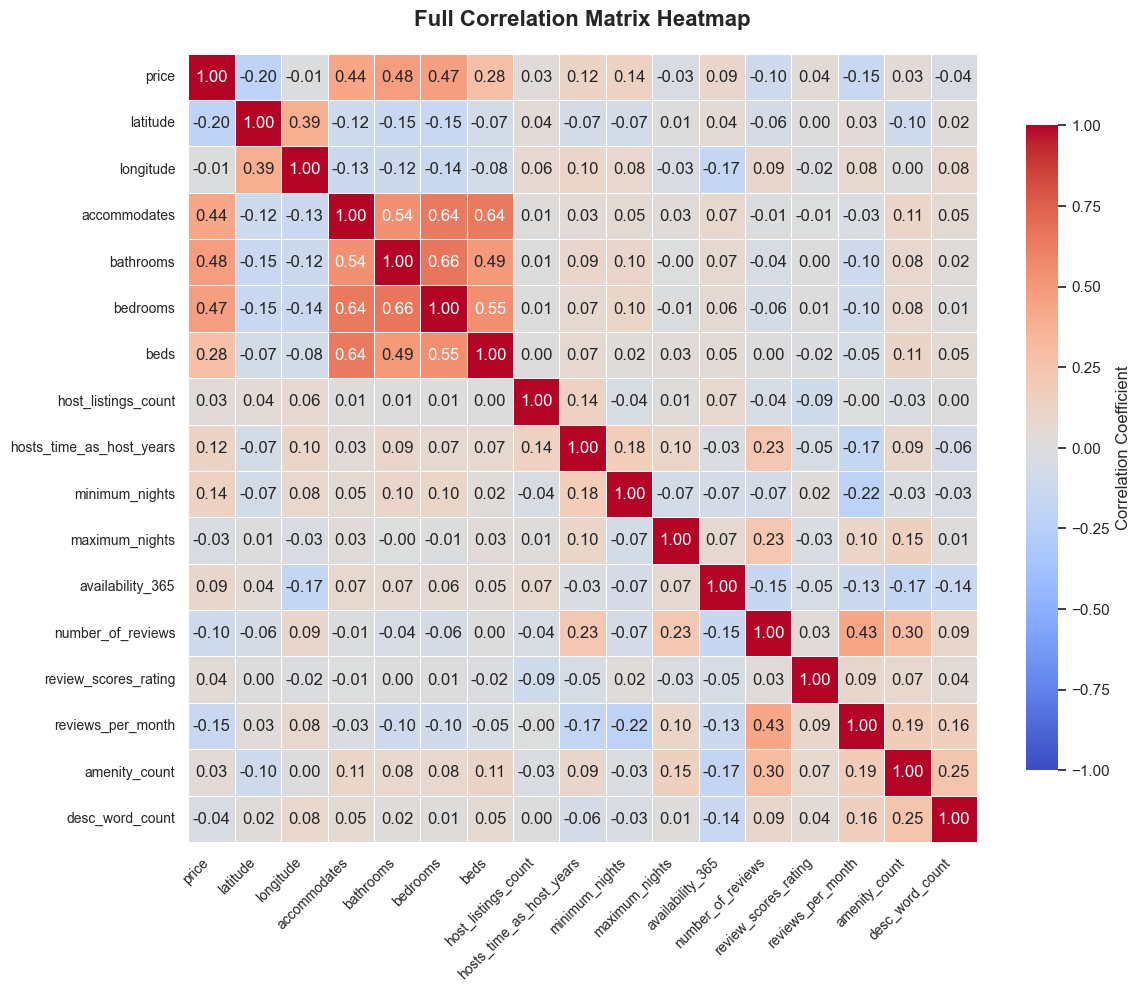

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the full square correlation matrix for all numerical features
numerical_df = df_final_features.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# 2. Setup the plotting window (Make it large enough so names aren't squished)
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

# 3. Create the full heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,           # Display the correlation numbers in each box
    fmt=".2f",            # Round to 2 decimal places
    cmap="coolwarm",      # Red-to-blue gradient (similar to your image's palette)
    vmin=-1, vmax=1,      # Fix boundaries from -1 to 1
    square=True,          # Force the cells to be perfect squares
    linewidths=0.5,       # Add fine white lines between the blocks
    cbar_kws={"shrink": .8, "label": "Correlation Coefficient"} # Clean up sidebar size
)

# Rotate labels slightly so long feature names are perfectly legible
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title("Full Correlation Matrix Heatmap", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the pristine dataset
df = df_final_features.copy()

# 2. SEVERE SAFEGUARD: Force-drop any lingering non-numeric text columns
# This strips out 'Santa Teresa' and any other unencoded categories automatically
X = df.drop(columns=['price'])
X = X.select_dtypes(include=[np.number]) 

y = df['price']

print("--- Data Verification ---")
print(f"Features count remaining for training: {X.shape[1]}")
print(f"Lingering text features dropped: {list(df.drop(columns=['price']).select_dtypes(exclude=[np.number]).columns)}")

# 3. Create a strict Train-Test Split (80% training, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDataset split complete: {X_train.shape[0]} training rows, {X_test.shape[0]} testing rows.\n")

# ==========================================
# MODEL 1: LINEAR REGRESSION
# ==========================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# ==========================================
# MODEL 2: RANDOM FOREST
# ==========================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# ==========================================
# EVALUATION MARATHON
# ==========================================
def print_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
    print(f"R² Score (Variance Explained):   {r2*100:.2f}%\n")

print_metrics("Linear Regression (Baseline)", y_test, lr_preds)
print_metrics("Random Forest (Ensemble)", y_test, rf_preds)

--- Data Verification ---
Features count remaining for training: 16
Lingering text features dropped: ['neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'amenities', 'host_is_superhost', 'has_availability', 'description', 'bathrooms_clean']

Dataset split complete: 31533 training rows, 7884 testing rows.

--- Linear Regression (Baseline) Performance ---
Mean Absolute Error (MAE):     $342.47
Root Mean Squared Error (RMSE): $584.35
R² Score (Variance Explained):   37.55%

--- Random Forest (Ensemble) Performance ---
Mean Absolute Error (MAE):     $285.85
Root Mean Squared Error (RMSE): $519.24
R² Score (Variance Explained):   50.70%



🔄 Optimizing parameters over 1000 epochs...
Epoch    1 | Current MSE Loss: 1065464.81
Epoch  200 | Current MSE Loss: 363302.94
Epoch  400 | Current MSE Loss: 363302.93
Epoch  600 | Current MSE Loss: 363302.93
Epoch  800 | Current MSE Loss: 363302.93
Epoch 1000 | Current MSE Loss: 363302.93

      GRADIENT DESCENT FROM SCRATCH RESULTS
Final R² Score:                 37.55%
Mean Absolute Error (MAE):     $342.47


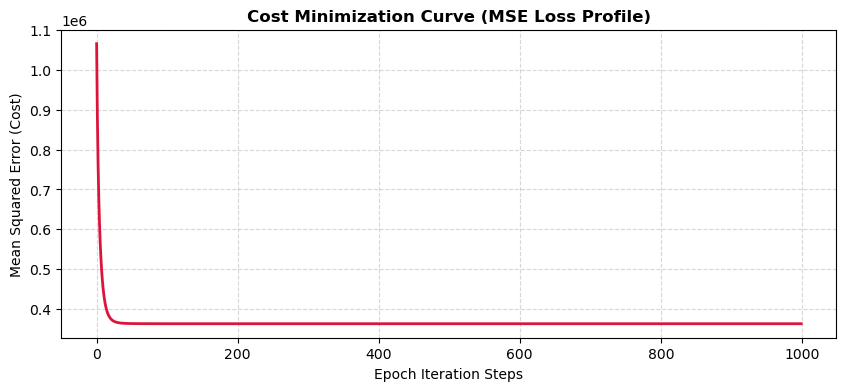

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load data matrix
df = df_final_features.copy()
X = df.drop(columns=['price']).select_dtypes(include=[np.number]).values
y = df['price'].values.reshape(-1, 1)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling (Crucial for Gradient Descent stability)
X_mean, X_std = np.mean(X_train, axis=0), np.std(X_train, axis=0)
X_std[X_std == 0] = 1.0  # Prevent division by zero
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

# ==================================================
# CUSTOM GRADIENT DESCENT ENGINE
# ==================================================
def fit_gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    n_samples, n_features = X.shape
    
    # Initialize weights to zeros and bias to zero
    w = np.zeros((n_features, 1))
    b = 0.0
    
    loss_history = []
    
    print(f"🔄 Optimizing parameters over {epochs} epochs...")
    for epoch in range(epochs):
        # 1. Compute predictions (y_hat = Xw + b)
        y_pred = np.dot(X, w) + b
        
        # 2. Calculate current MSE loss
        loss = np.mean((y_pred - y) ** 2)
        loss_history.append(loss)
        
        # 3. Compute Gradients (Partial Derivatives of MSE)
        dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (2 / n_samples) * np.sum(y_pred - y)
        
        # 4. Update Parameters along the negative gradient direction
        w -= learning_rate * dw
        b -= learning_rate * db
        
        if (epoch + 1) % 200 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:4d} | Current MSE Loss: {loss:.2f}")
            
    return w, b, loss_history

# 4. Train the custom parameters
learning_rate = 0.05
epochs = 1000
w, b, loss_history = fit_gradient_descent(X_train_scaled, y_train, learning_rate, epochs)

# 5. Evaluate on test set
gd_test_preds = np.dot(X_test_scaled, w) + b
gd_r2 = r2_score(y_test, gd_test_preds)
gd_mae = mean_absolute_error(y_test, gd_test_preds)

print("\n==================================================")
print("      GRADIENT DESCENT FROM SCRATCH RESULTS")
print("==================================================")
print(f"Final R² Score:                 {gd_r2*100:.2f}%")
print(f"Mean Absolute Error (MAE):     ${gd_mae:.2f}")
print("==================================================")

# 6. Plot the Cost Optimization Curve
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='crimson', lw=2)
plt.title('Cost Minimization Curve (MSE Loss Profile)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch Iteration Steps')
plt.ylabel('Mean Squared Error (Cost)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# If needed, run these in your terminal first:
# !pip install xgboost lightgbm

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb

# 1. Load data
df = df_final_features.copy()
X = df.drop(columns=['price']).select_dtypes(include=[np.number])
y = df['price']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features matrix shape: {X_train.shape}")

# ==========================================
# MODEL 4: LIGHTGBM
# ==========================================
print("\n⚡ Training LightGBM Regressor...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)

# ==========================================
# MODEL 5: XGBOOST
# ==========================================
print("🚀 Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# ==========================================
# PERFORMANCE SHOWDOWN
# ==========================================
def evaluate_booster(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {name} Performance ---")
    print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
    print(f"R² Score (Variance Explained):   {r2*100:.2f}%")

evaluate_booster("LightGBM", y_test, lgb_preds)
evaluate_booster("XGBoost", y_test, xgb_preds)

Features matrix shape: (31533, 16)

⚡ Training LightGBM Regressor...
🚀 Training XGBoost Regressor...

--- LightGBM Performance ---
Mean Absolute Error (MAE):     $275.58
Root Mean Squared Error (RMSE): $504.03
R² Score (Variance Explained):   53.54%

--- XGBoost Performance ---
Mean Absolute Error (MAE):     $273.22
Root Mean Squared Error (RMSE): $500.45
R² Score (Variance Explained):   54.20%


In [ ]:
# Install the library via terminal
# !pip install autogluon

from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split

# 1. Keep the raw columns intact (Keep description!)
df_raw_multimodal = df_final_features[['accommodates', 'bedrooms', 'beds', 'neighbourhood_cleansed', 'description', 'price']].copy()

# 2. Train-test split on raw mixed data types
train_data, test_data = train_test_split(df_raw_multimodal, test_size=0.2, random_state=42)

# 3. Fire up the AutoGluon Multimodal Tabular Engine
# It automatically detects 'description' as a text column and spins up a text transformer!
predictor = TabularPredictor(label='price', problem_type='regression').fit(
    train_data=train_data,
    hyperparameters={
        'GBM': {},            # LightGBM
        'XGB': {},            # XGBoost
        'AG_TEXT_NN': {}      # Deep Learning Text Transformer (BERT/DeBERTa)
    },
    time_limit=600            # Automatically optimizes everything it can within 10 minutes
)

# 4. Evaluate the multimodal boost
performance = predictor.evaluate(test_data)
print(performance)

No path specified. Models will be saved in: "AutogluonModels/ag-20260624_210536"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.15
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.5.0: Mon Apr 27 20:39:29 PDT 2026; root:xnu-12377.121.6~2/RELEASE_ARM64_T8142
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       7.59 GB / 24.00 GB (31.6%)
Disk Space Avail:   807.84 GB / 926.30 GB (87.2%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-ar

{'root_mean_squared_error': np.float64(-544.5191065654161), 'mean_squared_error': -296501.05741479894, 'mean_absolute_error': -305.3710795304111, 'r2': 0.4577761844260604, 'pearsonr': 0.6769099454242038, 'median_absolute_error': -174.86593627929688}


/opt/anaconda3/envs/autogluon_env/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# Split the filtered data
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Train XGBoost on filtered features
xgb_filtered = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
xgb_filtered.fit(X_train_f, y_train_f)
filtered_preds = xgb_filtered.predict(X_test_f)

print("==================================================")
print("       FILTERED XGBOOST PERFORMANCE RESULTS       ")
print("==================================================")
print(f"Filtered R² Score:               {r2_score(y_test_f, filtered_preds)*100:.2f}%")
print(f"Filtered Mean Absolute Error:    ${mean_absolute_error(y_test_f, filtered_preds):.2f}")
print("==================================================")

       FILTERED XGBOOST PERFORMANCE RESULTS       
Filtered R² Score:               47.22%
Filtered Mean Absolute Error:    $299.18


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# 1. Load data
df = df_final_features.copy()

# 2. Separate base numeric features and price
X_numeric = df.drop(columns=['price']).select_dtypes(include=[np.number])
y = df['price'].values.reshape(-1, 1)

# 3. Text parsing: Extract top 10 keywords from description
print("🔤 Transforming text descriptions into numeric columns...")
descriptions = df['description'].fillna('').astype(str)
tfidf = TfidfVectorizer(max_features=10, stop_words='english')
tfidf_matrix = tfidf.fit_transform(descriptions)

# Convert to dataframe
X_text_features = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=[f"text_{word}" for word in tfidf.get_feature_names_out()],
    index=df.index
)

# 4. Stitch them together into one unified numerical matrix
X_combined = pd.concat([X_numeric, X_text_features], axis=1).values
print(f"✅ Success! Your feature matrix now has {X_combined.shape[1]} numeric columns (including text markers).")

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# 6. Create scaled versions strictly for Linear/Gradient Descent models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

🔤 Transforming text descriptions into numeric columns...
✅ Success! Your feature matrix now has 26 numeric columns (including text markers).


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

print("🏋️‍♂️ Training all 5 models with text tokens appended...\n")

# ==========================================
# 1. LINEAR REGRESSION (Using Scaled Data)
# ==========================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# ==========================================
# 2. GRADIENT DESCENT FROM SCRATCH (Using Scaled Data)
# ==========================================
def fit_gradient_descent(X, y, learning_rate=0.05, epochs=600):
    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))
    b = 0.0
    for _ in range(epochs):
        y_pred = np.dot(X, w) + b
        dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (2 / n_samples) * np.sum(y_pred - y)
        w -= learning_rate * dw
        b -= learning_rate * db
    return w, b

w, b = fit_gradient_descent(X_train_scaled, y_train)
gd_preds = np.dot(X_test_scaled, w) + b

# ==========================================
# 3. RANDOM FOREST (Tree models handle raw or scaled perfectly)
# ==========================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train.ravel())
rf_preds = rf_model.predict(X_test)

# ==========================================
# 4. LIGHTGBM 
# ==========================================
lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbosity=-1, n_jobs=-1)
lgb_model.fit(X_train, y_train.ravel())
lgb_preds = lgb_model.predict(X_test)

# ==========================================
# 5. XGBOOST
# ==========================================
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# ==========================================
# THE SHOWDOWN SUMMARY
# ==========================================
def report(name, preds):
    print(f"{name:<30} | R² Score: {r2_score(y_test, preds)*100:.2f}% | MAE: ${mean_absolute_error(y_test, preds):.2f}")

print("=========================================================================")
print("             THE TEXT-INFUSED FEATURE SHOWDOWN RESULTS                   ")
print("=========================================================================")
report("1. Linear Regression", lr_preds)
report("2. Gradient Descent (Scratch)", gd_preds)
report("3. Random Forest", rf_preds)
report("4. LightGBM", lgb_preds)
report("5. XGBoost", xgb_preds)
print("=========================================================================")

🏋️‍♂️ Training all 5 models with text tokens appended...



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


             THE TEXT-INFUSED FEATURE SHOWDOWN RESULTS                   
1. Linear Regression           | R² Score: 37.77% | MAE: $341.97
2. Gradient Descent (Scratch)  | R² Score: 37.77% | MAE: $341.97
3. Random Forest               | R² Score: 49.14% | MAE: $289.19
4. LightGBM                    | R² Score: 53.55% | MAE: $276.19
5. XGBoost                     | R² Score: 53.99% | MAE: $275.36


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Fresh clone of your pristine feature matrix
df = df_final_features.copy()

# 2. Extract numeric columns and target variable
X = df.drop(columns=['price']).select_dtypes(include=[np.number])
y = df['price'].values.reshape(-1, 1)

# 3. Train-Test Split (80% training, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Standardize features (Crucial for Lasso regularization balance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# MODEL: LASSO REGRESSION (L1 Regularization)
# ==========================================
print("🎯 Training Lasso Regression Engine...")
# alpha=1.0 is the default penalty strength
lasso_model = Lasso(alpha=1.0, random_state=42, max_iter=3000)
lasso_model.fit(X_train_scaled, y_train)

# Predict
lasso_preds = lasso_model.predict(X_test_scaled)

# ==========================================
# EVALUATION METRICS
# ==========================================
lasso_r2 = r2_score(y_test, lasso_preds)
lasso_mae = mean_absolute_error(y_test, lasso_preds)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_preds))

print("\n==================================================")
print("             LASSO REGRESSION RESULTS             ")
print("==================================================")
print(f"R² Score (Variance Explained):   {lasso_r2*100:.2f}%")
print(f"Mean Absolute Error (MAE):     ${lasso_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${lasso_rmse:.2f}")
print("==================================================")

# ==========================================
# AUTOMATIC FEATURE SELECTION CHECK
# ==========================================
active_coefficients = np.sum(lasso_model.coef_ != 0)
zeroed_coefficients = np.sum(lasso_model.coef_ == 0)

print(f"\n💡 Lasso Feature Selection Profile:")
print(f"-> Active Features Retained: {active_coefficients}")
print(f"-> Features Dropped (Set to 0): {zeroed_coefficients} out of {X.shape[1]}")

🎯 Training Lasso Regression Engine...

             LASSO REGRESSION RESULTS             
R² Score (Variance Explained):   37.52%
Mean Absolute Error (MAE):     $341.99
Root Mean Squared Error (RMSE): $584.51

💡 Lasso Feature Selection Profile:
-> Active Features Retained: 16
-> Features Dropped (Set to 0): 0 out of 16


In [ ]:
import pandas as pd
import numpy as np

# 1. Fresh clone
df = df_final_features.copy()

# 2. Isolate numeric features and include the target 'price'
numeric_df = df.select_dtypes(include=[np.number])

# 3. Calculate correlation of everything with 'price'
correlations = numeric_df.corr()['price'].drop('price').sort_values(ascending=False)

print("==================================================")
print("       LINEAR CORRELATION WITH PRICE              ")
print("==================================================")
for col, val in correlations.items():
    print(f"{col:<30} : {val:.4f}")
print("==================================================\n")

# 4. SET THRESHOLD: Drop columns with less than 0.05 (5%) absolute correlation
threshold = 0.05
features_to_keep = correlations[abs(correlations) >= threshold].index.tolist()
features_to_drop = correlations[abs(correlations) < threshold].index.tolist()

print(f"✂️ Dropping {len(features_to_drop)} features below {threshold*100}% correlation threshold:")
print(features_to_drop)
print(f"\n✅ Keeping {len(features_to_keep)} features for the filtered dataset.")

# 5. Create the new filtered matrices
X_filtered = numeric_df[features_to_keep]
y_filtered = numeric_df['price'].values.reshape(-1, 1)

       LINEAR CORRELATION WITH PRICE              
bathrooms                      : 0.4769
bedrooms                       : 0.4710
accommodates                   : 0.4351
beds                           : 0.2767
minimum_nights                 : 0.1377
hosts_time_as_host_years       : 0.1183
availability_365               : 0.0894
review_scores_rating           : 0.0435
amenity_count                  : 0.0343
host_listings_count            : 0.0281
longitude                      : -0.0135
maximum_nights                 : -0.0348
desc_word_count                : -0.0389
number_of_reviews              : -0.1046
reviews_per_month              : -0.1456
latitude                       : -0.2035

✂️ Dropping 6 features below 5.0% correlation threshold:
['review_scores_rating', 'amenity_count', 'host_listings_count', 'longitude', 'maximum_nights', 'desc_word_count']

✅ Keeping 10 features for the filtered dataset.


In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# Split the filtered data
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Train XGBoost on filtered features
xgb_filtered = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
xgb_filtered.fit(X_train_f, y_train_f)
filtered_preds = xgb_filtered.predict(X_test_f)

print("==================================================")
print("       FILTERED XGBOOST PERFORMANCE RESULTS       ")
print("==================================================")
print(f"Filtered R² Score:               {r2_score(y_test_f, filtered_preds)*100:.2f}%")
print(f"Filtered Mean Absolute Error:    ${mean_absolute_error(y_test_f, filtered_preds):.2f}")
print("==================================================")

NameError: name 'X_filtered' is not defined

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load data
df = df_final_features.copy()
X = df.drop(columns=['price']).select_dtypes(include=[np.number])

# --- LOG TRANSFORMATION APPLIED HERE ---
# np.log1p computes log(1 + x) to safely handle any potential 0 values
y_log = np.log1p(df['price'])

# 2. Train-test split (Passing y_log instead of raw y)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 3. Standardize features (Crucial for Linear Regression and Gradient Descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features matrix shape: {X_train.shape}\n")
print("🏋️‍♂️ Training all 5 models with Log-Transformed Target...\n")

# ==========================================
# MODEL 1: LINEAR REGRESSION (Using Scaled Data)
# ==========================================
print("📈 Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log.ravel())
lr_preds_log = lr_model.predict(X_test_scaled)

# ==========================================
# MODEL 2: GRADIENT DESCENT FROM SCRATCH (Using Scaled Data)
# ==========================================
print("📉 Running Gradient Descent from Scratch...")
def fit_gradient_descent(X, y, learning_rate=0.05, epochs=600):
    n_samples, n_features = X.shape
    y = y.reshape(-1, 1)  # Ensure 2D shape for matrix math
    w = np.zeros((n_features, 1))
    b = 0.0
    for _ in range(epochs):
        y_pred = np.dot(X, w) + b
        dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (2 / n_samples) * np.sum(y_pred - y)
        w -= learning_rate * dw
        b -= learning_rate * db
    return w, b

w, b = fit_gradient_descent(X_train_scaled, y_train_log.ravel())
gd_preds_log = (np.dot(X_test_scaled, w) + b).flatten()

# ==========================================
# MODEL 3: RANDOM FOREST (Using Raw Data)
# ==========================================
print("🌳 Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_log.ravel())
rf_preds_log = rf_model.predict(X_test)

# ==========================================
# MODEL 4: LIGHTGBM (Using Raw Data)
# ==========================================
print("⚡ Training LightGBM Regressor...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train_log.ravel())
lgb_preds_log = lgb_model.predict(X_test)

# ==========================================
# MODEL 5: XGBOOST (Using Raw Data)
# ==========================================
print("🚀 Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train_log.ravel())
xgb_preds_log = xgb_model.predict(X_test)


# ==========================================
# PERFORMANCE SHOWDOWN EVALUATION FUNCTION
# ==========================================
def evaluate_model(name, y_true_log, y_pred_log):
    # 1. Reverse the log transformation to get actual dollar values
    y_true_actual = np.expm1(y_true_log)
    y_pred_actual = np.expm1(y_pred_log)
    
    # 2. Calculate metrics
    mae = mean_absolute_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    r2 = r2_score(y_true_log, y_pred_log)
    
    print(f"{name:<30} | R² Score: {r2*100:.2f}% | MAE: ${mae:.2f} | RMSE: ${rmse:.2f}")


print("\n=========================================================================================")
print("                       THE ULTIMATE 5-MODEL SHOWDOWN RESULTS                             ")
print("=========================================================================================")
evaluate_model("1. Linear Regression", y_test_log, lr_preds_log)
evaluate_model("2. Gradient Descent (Scratch)", y_test_log, gd_preds_log)
evaluate_model("3. Random Forest", y_test_log, rf_preds_log)
evaluate_model("4. LightGBM", y_test_log, lgb_preds_log)
evaluate_model("5. XGBoost", y_test_log, xgb_preds_log)
print("=========================================================================================")

Features matrix shape: (31533, 16)

🏋️‍♂️ Training all 5 models with Log-Transformed Target...

📈 Training Linear Regression...
📉 Running Gradient Descent from Scratch...
🌳 Training Random Forest Regressor...


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/1294774777.py:35: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  lr_model.fit(X_train_scaled, y_train_log.ravel())
/opt/anaconda3/envs/autogluon_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/autogluon_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/autogluon_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/1294774777.py:55: FutureWarning: Series.ravel is deprecated. The underlying ar

⚡ Training LightGBM Regressor...


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/1294774777.py:78: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  lgb_model.fit(X_train, y_train_log.ravel())


🚀 Training XGBoost Regressor...


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/1294774777.py:92: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  xgb_model.fit(X_train, y_train_log.ravel())



                       THE ULTIMATE 5-MODEL SHOWDOWN RESULTS                             
1. Linear Regression           | R² Score: 43.37% | MAE: $306.56 | RMSE: $605.77
2. Gradient Descent (Scratch)  | R² Score: 43.37% | MAE: $306.56 | RMSE: $605.77
3. Random Forest               | R² Score: 59.32% | MAE: $262.25 | RMSE: $528.83
4. LightGBM                    | R² Score: 61.59% | MAE: $258.31 | RMSE: $518.48
5. XGBoost                     | R² Score: 61.74% | MAE: $255.68 | RMSE: $513.85


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/3055310388.py:7: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_true_actual = np.expm1(y_test_log).ravel()


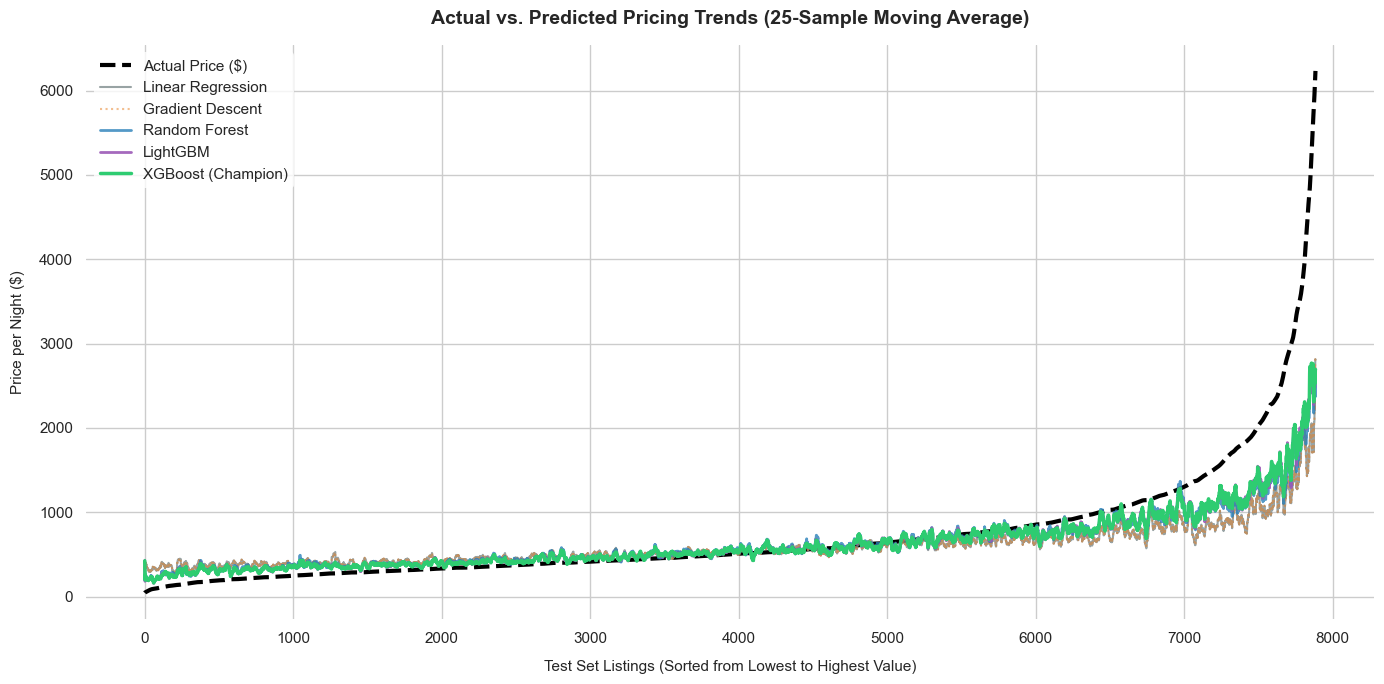

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare data and convert back from log-space to actual dollars
y_true_actual = np.expm1(y_test_log).ravel()

plot_df = pd.DataFrame({
    'Actual Price': y_true_actual,
    'Linear Regression': np.expm1(lr_preds_log).ravel(),
    'Gradient Descent': np.expm1(gd_preds_log).ravel(),
    'Random Forest': np.expm1(rf_preds_log).ravel(),
    'LightGBM': np.expm1(lgb_preds_log).ravel(),
    'XGBoost': np.expm1(xgb_preds_log).ravel()
})

# Sort by actual price to establish a clean left-to-right baseline trend
plot_df = plot_df.sort_values(by='Actual Price').reset_index(drop=True)

# Apply a rolling window mean (e.g., 25 samples) to smooth out variance spikes
# This makes the line chart look clean and easily readable
rolling_df = plot_df.rolling(window=25, min_periods=1).mean()

# 2. Design the Line Graph Canvas
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Plot the Actual baseline
plt.plot(rolling_df['Actual Price'], label='Actual Price ($)', color='black', linewidth=3, linestyle='--')

# Plot the Models
plt.plot(rolling_df['Linear Regression'], label='Linear Regression', color='#7f8c8d', alpha=0.8, linewidth=1.5)
plt.plot(rolling_df['Gradient Descent'], label='Gradient Descent', color='#e67e22', alpha=0.5, linewidth=1.5, linestyle=':')
plt.plot(rolling_df['Random Forest'], label='Random Forest', color='#2980b9', alpha=0.8, linewidth=2)
plt.plot(rolling_df['LightGBM'], label='LightGBM', color='#9b59b6', alpha=0.9, linewidth=2)
plt.plot(rolling_df['XGBoost'], label='XGBoost (Champion)', color='#2ecc71', alpha=1, linewidth=2.5)

# Styling and Details
plt.title("Actual vs. Predicted Pricing Trends (25-Sample Moving Average)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Test Set Listings (Sorted from Lowest to Highest Value)", fontsize=11, labelpad=10)
plt.ylabel("Price per Night ($)", fontsize=11, labelpad=10)

# Limit the view slightly if you have massive price outliers distorting the scale
# plt.ylim(0, plot_df['Actual Price'].quantile(0.98)) 

plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11, loc='upper left')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Original dataset rows: 39417
Filtered dataset rows (Price <= $1500): 36110
Removed 3307 extreme luxury outliers.

🏋️‍♂️ Re-training top tree models on filtered data...



/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/415621916.py:42: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  rf_model_f.fit(X_train_f, y_train_log_f.ravel())
/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/415621916.py:47: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  lgb_model_f.fit(X_train_f, y_train_log_f.ravel())
/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/415621916.py:52: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  xgb_model_f.fit(X_train_f, y_train_log_f.ravel())


Random Forest   -> New R²: 55.81% | New MAE: $151.80
LightGBM        -> New R²: 56.70% | New MAE: $150.96
XGBoost         -> New R²: 56.91% | New MAE: $150.06


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/415621916.py:58: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_true_actual_f = np.expm1(y_test_log_f).ravel()
/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/415621916.py:72: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  r2 = r2_score(y_test_log_f.ravel(), preds.ravel()) * 100
/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/415621916.py:72: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  r2 = r2_score(y_test_log_f.ravel(), preds.ravel()) * 100
/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/415621916.py:72: FutureWa

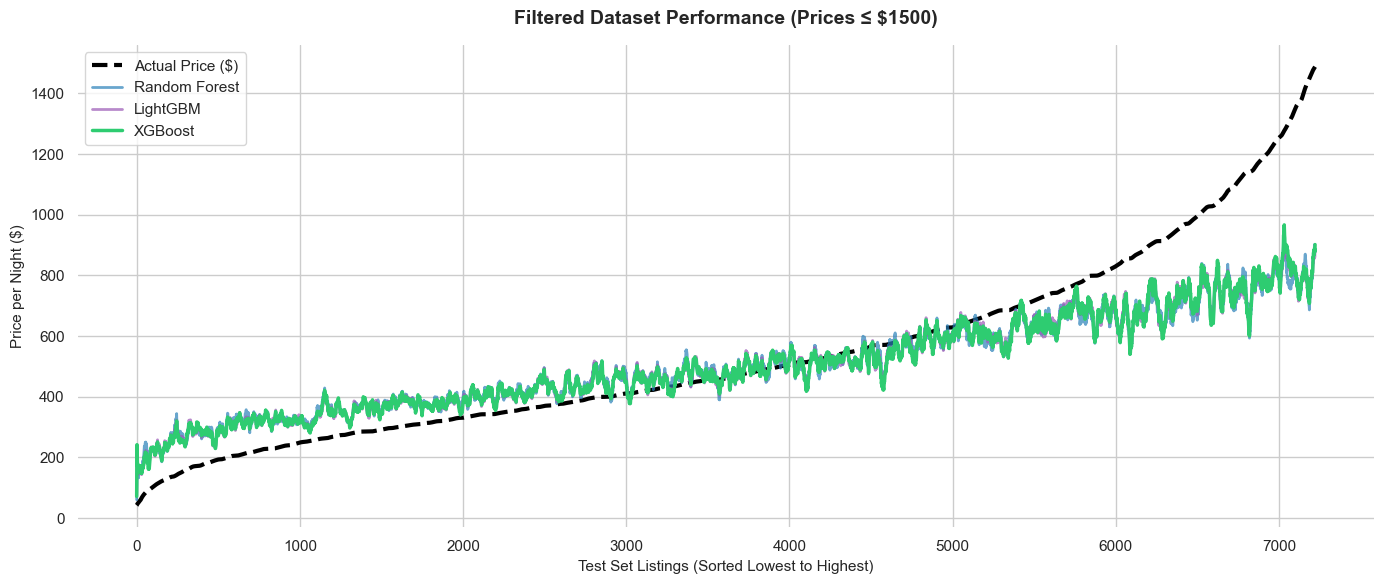

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. CREATE SAFE COPY & FILTER OUTLIERS
# ==========================================
# Create an explicit copy so df_final_features remains pristine
df_filtered = df_final_features.copy()

# Filter out extreme luxury outliers
df_filtered = df_filtered[df_filtered['price'] <= 1500]

print(f"Original dataset rows: {df_final_features.shape[0]}")
print(f"Filtered dataset rows (Price <= $1500): {df_filtered.shape[0]}")
print(f"Removed {df_final_features.shape[0] - df_filtered.shape[0]} extreme luxury outliers.\n")

# ==========================================
# 2. PREPARE X AND Y (WITH LOG TRANSFORMATION)
# ==========================================
X_filt = df_filtered.drop(columns=['price']).select_dtypes(include=[np.number])
y_log_filt = np.log1p(df_filtered['price'])

X_train_f, X_test_f, y_train_log_f, y_test_log_f = train_test_split(
    X_filt, y_log_filt, test_size=0.2, random_state=42
)

print("🏋️‍♂️ Re-training top tree models on filtered data...\n")

# ==========================================
# 3. TRAIN TOP 3 WINNING MODELS
# ==========================================
# Model 1: Random Forest
rf_model_f = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_f.fit(X_train_f, y_train_log_f.ravel())
rf_preds_f = rf_model_f.predict(X_test_f)

# Model 2: LightGBM
lgb_model_f = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbosity=-1, n_jobs=-1)
lgb_model_f.fit(X_train_f, y_train_log_f.ravel())
lgb_preds_f = lgb_model_f.predict(X_test_f)

# Model 3: XGBoost
xgb_model_f = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
xgb_model_f.fit(X_train_f, y_train_log_f.ravel())
xgb_preds_f = xgb_model_f.predict(X_test_f)

# ==========================================
# 4. EVALUATE & GENERATE NEW TREND LINE GRAPH
# ==========================================
y_true_actual_f = np.expm1(y_test_log_f).ravel()

plot_df_f = pd.DataFrame({
    'Actual Price': y_true_actual_f,
    'Random Forest': np.expm1(rf_preds_f).ravel(),
    'LightGBM': np.expm1(lgb_preds_f).ravel(),
    'XGBoost': np.expm1(xgb_preds_f).ravel()
}).sort_values(by='Actual Price').reset_index(drop=True)

# Smoothing the curves for clear visual trends
rolling_df_f = plot_df_f.rolling(window=25, min_periods=1).mean()

# Calculate performance metrics for the title/legend context
for name, preds in [("Random Forest", rf_preds_f), ("LightGBM", lgb_preds_f), ("XGBoost", xgb_preds_f)]:
    r2 = r2_score(y_test_log_f.ravel(), preds.ravel()) * 100
    mae = mean_absolute_error(y_true_actual_f, np.expm1(preds).ravel())
    print(f"{name:<15} -> New R²: {r2:.2f}% | New MAE: ${mae:.2f}")

# Plotting the updated results
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

plt.plot(rolling_df_f['Actual Price'], label='Actual Price ($)', color='black', linewidth=3, linestyle='--')
plt.plot(rolling_df_f['Random Forest'], label='Random Forest', color='#2980b9', alpha=0.7, linewidth=2)
plt.plot(rolling_df_f['LightGBM'], label='LightGBM', color='#9b59b6', alpha=0.7, linewidth=2)
plt.plot(rolling_df_f['XGBoost'], label='XGBoost', color='#2ecc71', alpha=1, linewidth=2.5)

plt.title("Filtered Dataset Performance (Prices ≤ $1500)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Test Set Listings (Sorted Lowest to Highest)", fontsize=11)
plt.ylabel("Price per Night ($)", fontsize=11)
plt.legend(frameon=True, facecolor='white', loc='upper left')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [41]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Setup
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# 2. Load Reviews (Sample 50k to keep it fast)
print("Processing reviews... this takes about 1 minute.")
reviews = pd.read_csv('../data/raw/reviews.csv.gz', nrows=50000)
reviews = reviews.dropna(subset=['comments'])

# 3. Calculate Sentiment
def get_sentiment(text):
    return sia.polarity_scores(str(text))['compound']

reviews['sentiment_score'] = reviews['comments'].apply(get_sentiment)

# 4. Group by listing_id
df_sentiment = reviews.groupby('listing_id')['sentiment_score'].mean().reset_index()

print("Sentiment Scores Created!")
df_sentiment.head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jnanadeep/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Processing reviews... this takes about 1 minute.
Sentiment Scores Created!


,listing_id,sentiment_score
0,17878,0.593567
1,25026,0.556820
2,35764,0.340955
3,48305,0.553079
4,48901,0.009629


In [86]:
# 1. Load Listings
df_new = df_final_features.copy()

# 3. MERGE: Add Sentiment to Listings
# We match 'id' from listings with 'listing_id' from reviews
df_new = pd.merge(df_new, df_sentiment, left_on='id', right_on='listing_id', how='left')

# If a house has no reviews, give it 0 (neutral)
df_new['sentiment_score'] = df_new['sentiment_score'].fillna(0)

print("Merging Complete! Your data is now Multimodal.")

Merging Complete! Your data is now Multimodal.


In [88]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load data and clean missing values
df = df_new.copy()

# --- FIX: Drop missing values so Linear Regression doesn't crash ---
df = df.dropna() 

X = df.drop(columns=['price']).select_dtypes(include=[np.number])

# --- LOG TRANSFORMATION APPLIED HERE ---
y_log = np.log1p(df['price'])

# 2. Train-test split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 3. Standardize features (Crucial for Linear Regression and Gradient Descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features matrix shape after dropping NaNs: {X_train.shape}\n")
print("🏋️‍♂️ Training all 5 models with Log-Transformed Target...\n")

# ==========================================
# MODEL 1: LINEAR REGRESSION (Using Scaled Data)
# ==========================================
print("📈 Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log.ravel())
lr_preds_log = lr_model.predict(X_test_scaled)

# ==========================================
# MODEL 2: GRADIENT DESCENT FROM SCRATCH (Using Scaled Data)
# ==========================================
print("📉 Running Gradient Descent from Scratch...")
def fit_gradient_descent(X, y, learning_rate=0.05, epochs=600):
    n_samples, n_features = X.shape
    y = y.reshape(-1, 1)  
    w = np.zeros((n_features, 1))
    b = 0.0
    for _ in range(epochs):
        y_pred = np.dot(X, w) + b
        dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (2 / n_samples) * np.sum(y_pred - y)
        w -= learning_rate * dw
        b -= learning_rate * db
    return w, b

w, b = fit_gradient_descent(X_train_scaled, y_train_log.ravel())
gd_preds_log = (np.dot(X_test_scaled, w) + b).flatten()

# ==========================================
# MODEL 3: RANDOM FOREST (Using Raw Data)
# ==========================================
print("🌳 Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_log.ravel())
rf_preds_log = rf_model.predict(X_test)

# ==========================================
# MODEL 4: LIGHTGBM (Using Raw Data)
# ==========================================
print("⚡ Training LightGBM Regressor...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train_log.ravel())
lgb_preds_log = lgb_model.predict(X_test)

# ==========================================
# MODEL 5: XGBOOST (Using Raw Data)
# ==========================================
print("🚀 Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train_log.ravel())
xgb_preds_log = xgb_model.predict(X_test)


# ==========================================
# PERFORMANCE SHOWDOWN EVALUATION FUNCTION
# ==========================================
def evaluate_model(name, y_true_log, y_pred_log):
    y_true_actual = np.expm1(y_true_log)
    y_pred_actual = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    r2 = r2_score(y_true_log, y_pred_log)
    
    print(f"{name:<30} | R² Score: {r2*100:.2f}% | MAE: ${mae:.2f} | RMSE: ${rmse:.2f}")


print("\n=========================================================================================")
print("                        THE ULTIMATE 5-MODEL SHOWDOWN RESULTS                             ")
print("=========================================================================================")
evaluate_model("1. Linear Regression", y_test_log, lr_preds_log)
evaluate_model("2. Gradient Descent (Scratch)", y_test_log, gd_preds_log)
evaluate_model("3. Random Forest", y_test_log, rf_preds_log)
evaluate_model("4. LightGBM", y_test_log, lgb_preds_log)
evaluate_model("5. XGBoost", y_test_log, xgb_preds_log)
print("=========================================================================================")

Features matrix shape after dropping NaNs: (297, 17)

🏋️‍♂️ Training all 5 models with Log-Transformed Target...

📈 Training Linear Regression...
📉 Running Gradient Descent from Scratch...
🌳 Training Random Forest Regressor...
⚡ Training LightGBM Regressor...


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/277270835.py:38: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  lr_model.fit(X_train_scaled, y_train_log.ravel())
/opt/anaconda3/envs/autogluon_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/autogluon_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/autogluon_env/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/277270835.py:58: FutureWarning: Series.ravel is deprecated. The underlying arra

🚀 Training XGBoost Regressor...


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_63476/277270835.py:95: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  xgb_model.fit(X_train, y_train_log.ravel())



                        THE ULTIMATE 5-MODEL SHOWDOWN RESULTS                             
1. Linear Regression           | R² Score: 42.67% | MAE: $267.06 | RMSE: $402.34
2. Gradient Descent (Scratch)  | R² Score: 42.62% | MAE: $266.82 | RMSE: $402.21
3. Random Forest               | R² Score: 49.72% | MAE: $276.98 | RMSE: $472.68
4. LightGBM                    | R² Score: 38.29% | MAE: $327.19 | RMSE: $543.08
5. XGBoost                     | R² Score: 39.07% | MAE: $292.04 | RMSE: $502.75
